In [1]:
#For Arrays and Mathematical Operations
import numpy as np

#For Pandas Dataframe
import pandas as pd

#For Graphing
import seaborn as sns
import matplotlib.pyplot as plt

#For Scaling the Numerical Columns
from sklearn.preprocessing import StandardScaler

#For detecting outliers
from scipy.stats import zscore

#For Encoding Categorical Columns
%pip install category_encoders
import category_encoders as ce

#For Oversampling the Data
from imblearn.over_sampling import SMOTE

#For Splitting the data into training and testing
from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.


# **Detecting Fraud Through Transaction Pattern Analysis**

## About the Data

This dataset is designed to help data scientists and machine learning enthusiasts develop robust fraud detection models. It contains realistic synthetic transaction data, including user information, transaction types, risk scores, and more, making it ideal for binary classification tasks with models like XGBoost and LightGBM.

| Column Name                  | Description                                                         |
| ---------------------------- | ------------------------------------------------------------------- |
| Transaction_ID               | Unique identifier for each transaction                              |
| User_ID                      | Unique identifier for the user                                      |
| Transaction_Amount           | Amount of money involved in the transaction                         |
| Transaction_Type             | Type of transaction (Online, In-Store, ATM, etc.)                   |
| Timestamp                    | Date and time of the transaction                                    |
| Account_Balance              | User's current account balance before the transaction               |
| Device_Type                  | Type of device used (Mobile, Desktop, etc.)                         |
| Location                     | Geographical location of the transaction                            |
| Merchant_Category            | Type of merchant (Retail, Food, Travel, etc.)                       |
| IP_Address_Flag              | Whether the IP address was flagged as suspicious (0 or 1)           |
| Previous_Fraudulent_Activity | Number of past fraudulent activities by the user                    |
| Daily_Transaction_Count      | Number of transactions made by the user that day                    |
| Avg_Transaction_Amount_7d    | User's average transaction amount in the past 7 days                |
| Failed_Transaction_Count_7d  | Count of failed transactions in the past 7 days                     |
| Card_Type                    | Type of payment card used (Credit, Debit, Prepaid, etc.)            |
| Card_Age                     | Age of the card in months                                           |
| Transaction_Distance         | Distance between the user's usual location and transaction location |
| Authentication_Method        | How the user authenticated (PIN, Biometric, etc.)                   |
| Risk_Score                   | Fraud risk score computed for the transaction                       |
| Is_Weekend                   | Whether the transaction occurred on a weekend (0 or 1)              |
| Fraud_Label                  | Target variable (0 = Not Fraud, 1 = Fraud)                          |


In [2]:
df = pd.read_csv('synthetic_fraud_dataset.csv')

In [3]:
df

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TXN_11284,USER_4796,45.05,Online,2023-01-29 18:38:00,76960.11,Mobile,Tokyo,Clothing,0,...,2,389.00,3,Amex,98,1537.54,PIN,0.1493,1,0
49996,TXN_44732,USER_1171,126.15,POS,2023-05-09 08:55:00,28791.75,Mobile,Tokyo,Clothing,0,...,13,434.95,4,Visa,93,2555.72,Biometric,0.3653,0,1
49997,TXN_38158,USER_2510,72.02,Online,2023-01-30 19:32:00,29916.41,Laptop,Mumbai,Clothing,0,...,1,369.15,2,Visa,114,4686.59,Biometric,0.5195,0,0
49998,TXN_860,USER_2248,64.89,Bank Transfer,2023-03-09 19:47:00,67895.67,Mobile,Tokyo,Electronics,0,...,13,242.29,4,Discover,72,4886.92,Biometric,0.7063,0,1


In [4]:
desc = df.describe().drop(index=['25%', '50%', '75%'])
desc.loc['median'] = df.median(numeric_only=True)

desc

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.05020,0.098400,7.485240,255.271924,2.003540,119.999940,2499.164155,0.501556,0.299640,0.321340
std,98.687292,28760.458557,0.21836,0.297858,4.039637,141.382279,1.414273,68.985817,1442.013834,0.287774,0.458105,0.466996
min,0.000000,500.480000,0.00000,0.000000,1.000000,10.000000,0.000000,1.000000,0.250000,0.000100,0.000000,0.000000
max,1174.140000,99998.310000,1.00000,1.000000,14.000000,500.000000,4.000000,239.000000,4999.930000,1.000000,1.000000,1.000000
median,69.660000,50384.430000,0.00000,0.000000,7.000000,256.085000,2.000000,120.000000,2490.785000,0.502250,0.000000,0.000000


In [5]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label'],
      dtype='object')

## Data Exploration

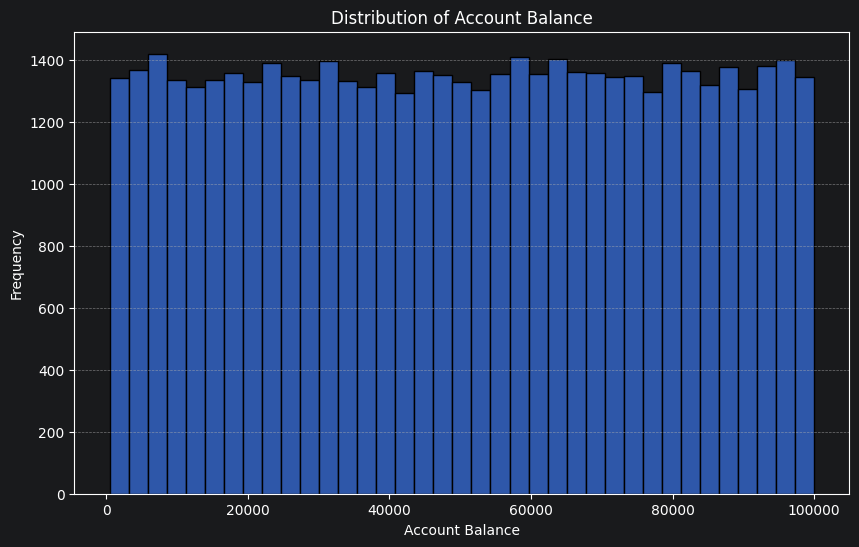

In [6]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Account_Balance'])
plt.title('Distribution of Account Balance')
plt.xlabel('Account Balance')
plt.ylabel('Frequency')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

The histogram shows that account balances are distributed almost uniformly across the full range, from roughly 0 to 100,000. The bars are all very similar in height, mostly around 1,300 to 1,400 observations per bin, which means no particular balance range is much more common than another. There is no strong skew, clustering, or visible outlier pattern. This suggests the account balance variable in the synthetic dataset was likely generated from a uniform distribution rather than from a real-world financial distribution, where lower or middle balances would usually be more concentrated and very high balances would be less frequent.

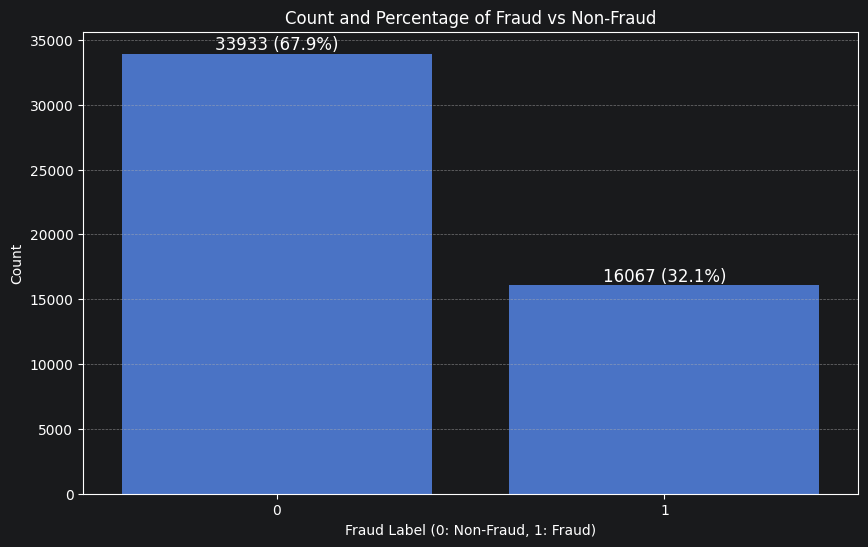

In [7]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Fraud_Label', data=df)
plt.title('Count and Percentage of Fraud vs Non-Fraud')
plt.xlabel('Fraud Label (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{count} ({percentage})', (x, y), ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

The chart shows the class distribution for the synthetic fraud dataset. There are 33,933 non-fraud transactions, representing 67.9% of the dataset, and 16,067 fraud transactions, representing 32.1%. This means the dataset is imbalanced, with non-fraud cases appearing a little more than twice as often as fraud cases.

For fraud detection, this imbalance matters because a model could achieve decent overall accuracy by leaning toward the majority non-fraud class, while still missing many fraudulent transactions. However, the imbalance is not extreme; fraud makes up nearly one-third of the data, which is much higher than in many real-world fraud datasets. Because of that, accuracy should not be the only evaluation metric. Precision, recall, F1-score, confusion matrix results, and possibly ROC-AUC or PR-AUC would give a clearer picture of how well the model identifies fraud.

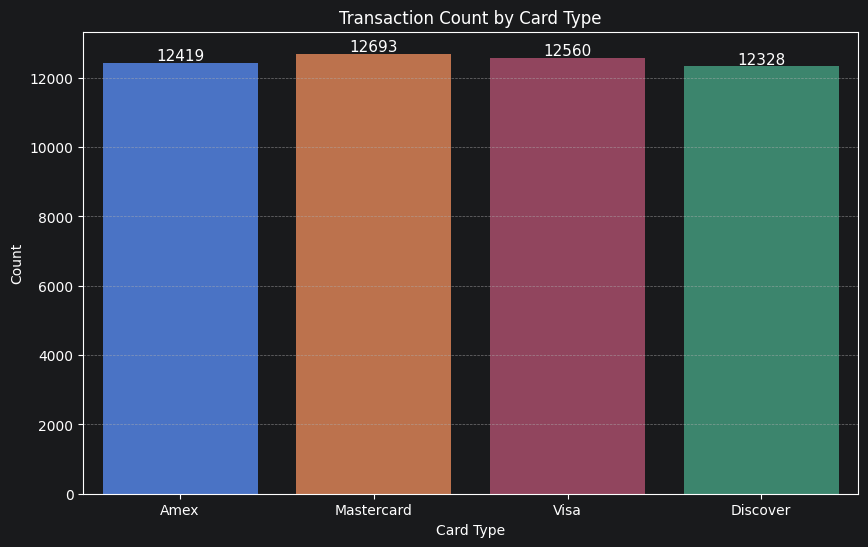

In [8]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Card_Type', data=df, hue='Card_Type')
plt.title('Transaction Count by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=11, color='white', xytext=(0, 5), textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

The chart shows that transaction counts are very evenly distributed across the four card types. Mastercard has the highest count with 12,693 transactions, followed closely by Visa with 12,560, Amex with 12,419, and Discover with 12,328. The difference between the most common and least common card type is only 365 transactions, which is small relative to the overall dataset size.

This balanced distribution suggests that card type is not dominated by any single category in the dataset. From a modeling perspective, this is helpful because the model should have roughly similar exposure to each card type during training. However, this chart only shows transaction volume, not fraud behavior. To understand whether card type is useful for fraud detection, it would be important to compare fraud rates within each card type rather than just total transaction counts.

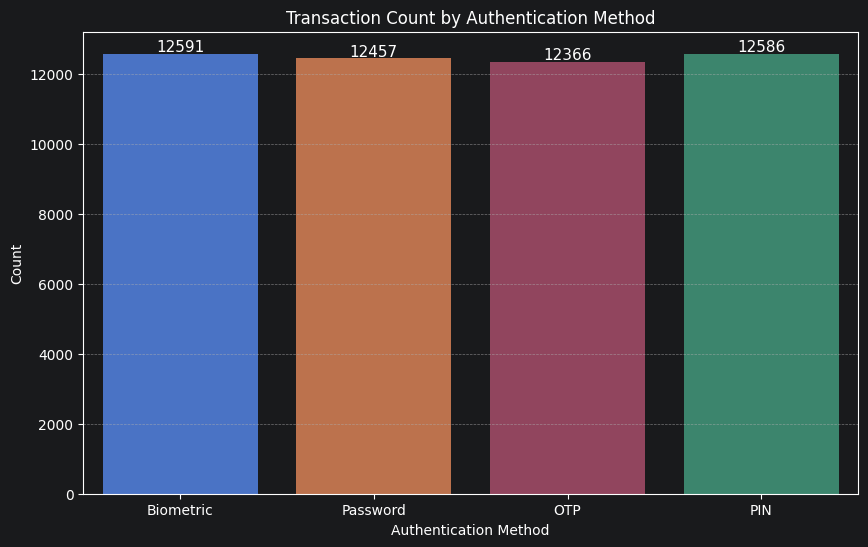

In [9]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Authentication_Method', data=df, hue='Authentication_Method')
plt.title('Transaction Count by Authentication Method')
plt.xlabel('Authentication Method')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=11, color='white', xytext=(0, 5), textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

The chart shows that transactions are almost evenly distributed across the four authentication methods. Biometric authentication has the highest count with 12,591 transactions, followed very closely by PIN with 12,586, Password with 12,457, and OTP with 12,366. The spread between the highest and lowest category is only 225 transactions, so there is no major imbalance in authentication method usage.

This means the dataset gives roughly equal representation to each authentication method, which is useful for analysis and modeling because no single method dominates the data. However, this chart only shows how often each authentication method appears, not whether one method is associated with more fraud. To determine whether authentication method is predictive of fraud, the next step would be to compare fraud rates within each method, such as the percentage of OTP transactions that are fraudulent versus biometric, password, and PIN transactions.

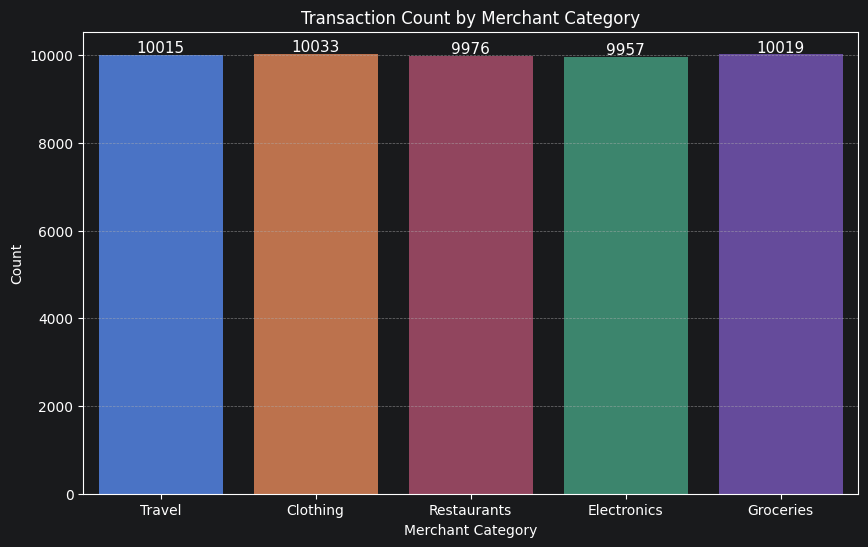

In [10]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Merchant_Category', data=df, hue='Merchant_Category')
plt.title('Transaction Count by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=11, color='white', xytext=(0, 5), textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

The chart shows that transactions are almost perfectly balanced across merchant categories. Clothing has the highest count with 10,033 transactions, followed by Groceries with 10,019, Travel with 10,015, Restaurants with 9,976, and Electronics with 9,957. The difference between the largest and smallest category is only 76 transactions, which is very small compared with the overall dataset size.

This balanced distribution means no merchant category dominates the dataset, so each category is represented at roughly the same level. That is helpful for analysis and modeling because the model has similar exposure to each type of merchant. However, this chart only shows total transaction volume by category. To understand whether merchant category is related to fraud, it would be more useful to compare the fraud rate within each category rather than just the number of transactions.

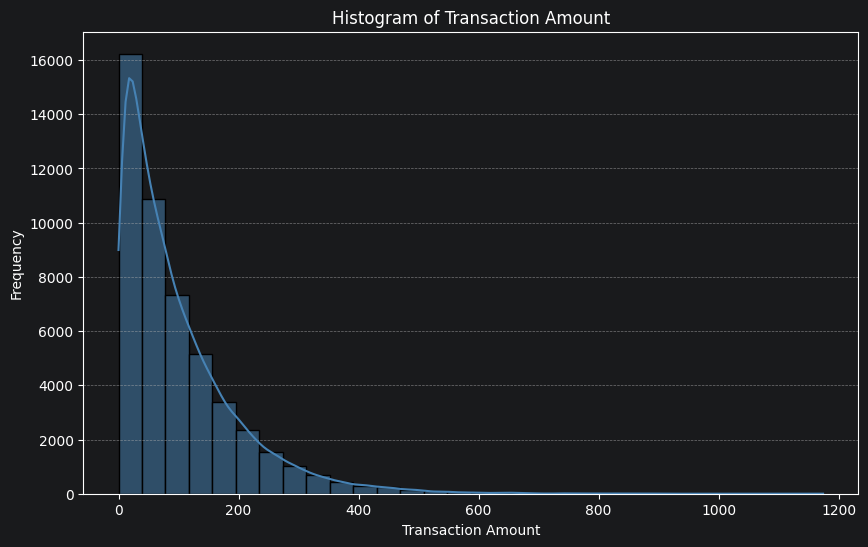

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Transaction_Amount'], bins=30, kde=True, color='steelblue')
plt.title('Histogram of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

The histogram shows that transaction amounts are strongly right-skewed. Most transactions are small, concentrated near the lower end of the amount range, while the frequency drops quickly as transaction amounts increase. There is a long tail extending toward much larger amounts, reaching above 1,000, but those high-value transactions are rare compared with the smaller ones.

This distribution suggests that typical spending behavior in the dataset is dominated by low-value transactions, with a smaller number of unusually large purchases. For fraud detection, this matters because transaction amount may be an important feature, especially if fraudulent transactions are more common in certain amount ranges. Because the variable is skewed, using the raw transaction amount directly may affect some models. A log transformation or scaling approach could help make the feature more useful, especially for models sensitive to feature distribution.

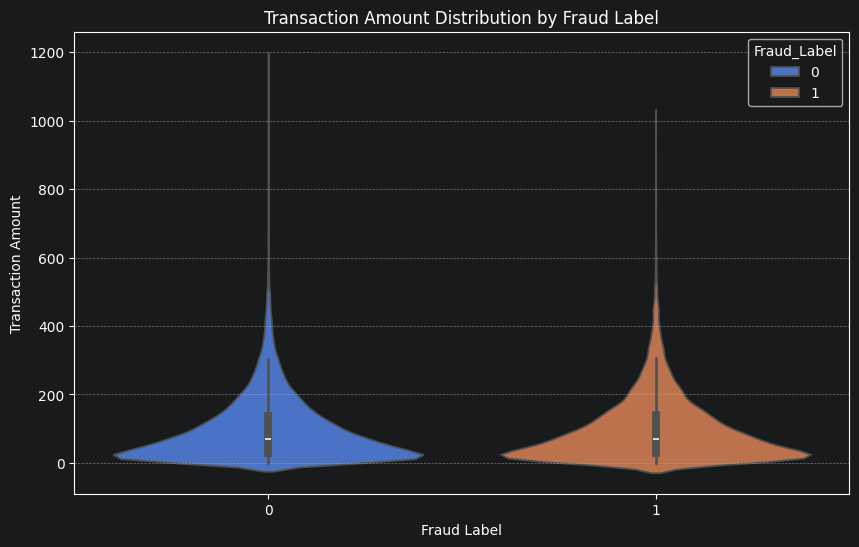

In [12]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Fraud_Label', y='Transaction_Amount', data=df, hue = 'Fraud_Label')
plt.title('Transaction Amount Distribution by Fraud Label')
plt.xlabel('Fraud Label')
plt.ylabel('Transaction Amount')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

The violin plot compares transaction amount distributions for non-fraud transactions labeled 0 and fraud transactions labeled 1. Both groups have very similar shapes: most transactions are concentrated at lower amounts, with long upper tails showing that a small number of transactions reach much higher values. This matches the earlier histogram, where transaction amounts were strongly right-skewed.

The fraud and non-fraud distributions appear to overlap heavily, which suggests that transaction amount alone may not clearly separate fraudulent from legitimate transactions. Fraudulent transactions do show a long tail as well, but the overall spread and central range look close to the non-fraud group. For modeling, transaction amount may still be useful when combined with other features, but by itself it is unlikely to be a strong fraud indicator. A more detailed comparison using group means, medians, quartiles, or fraud rate by amount ranges would help confirm whether high-value transactions carry more fraud risk.

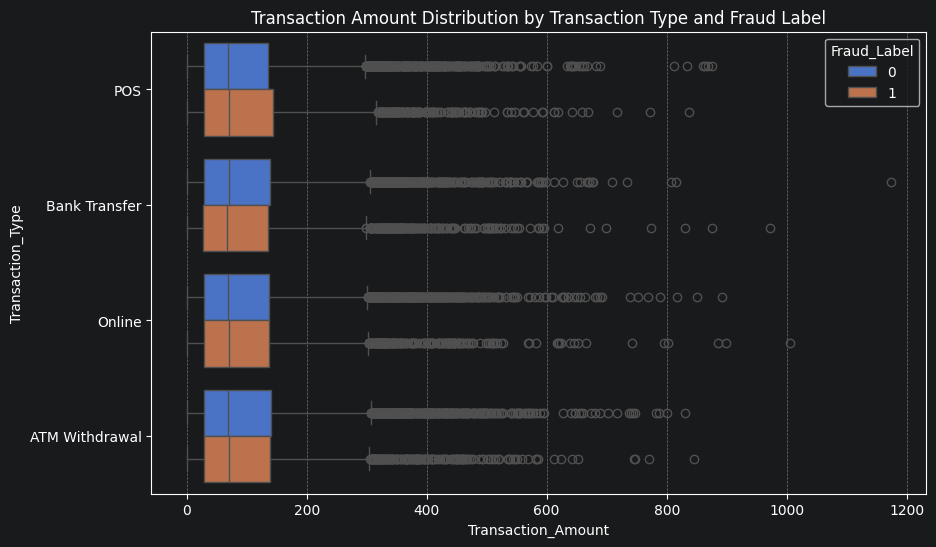

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(y='Transaction_Type', x='Transaction_Amount', data=df, hue = 'Fraud_Label')
plt.title('Transaction Amount Distribution by Transaction Type and Fraud Label')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

The boxplot shows transaction amount distributions across transaction types, separated by fraud label. For POS, Bank Transfer, Online, and ATM Withdrawal transactions, the fraud and non-fraud groups look very similar. Their medians and interquartile ranges are close, meaning the typical transaction amounts do not differ much between fraudulent and legitimate transactions within each transaction type.

All transaction types show a strong right-skew, with many high-value outliers extending far beyond the main concentration of transactions. Bank Transfer and Online transactions include some of the largest outliers, reaching close to or above 1,000, but these high amounts appear in both fraud and non-fraud groups. Overall, the chart suggests that transaction amount by transaction type is not enough on its own to clearly identify fraud, though it may still help when combined with other variables in a predictive model.

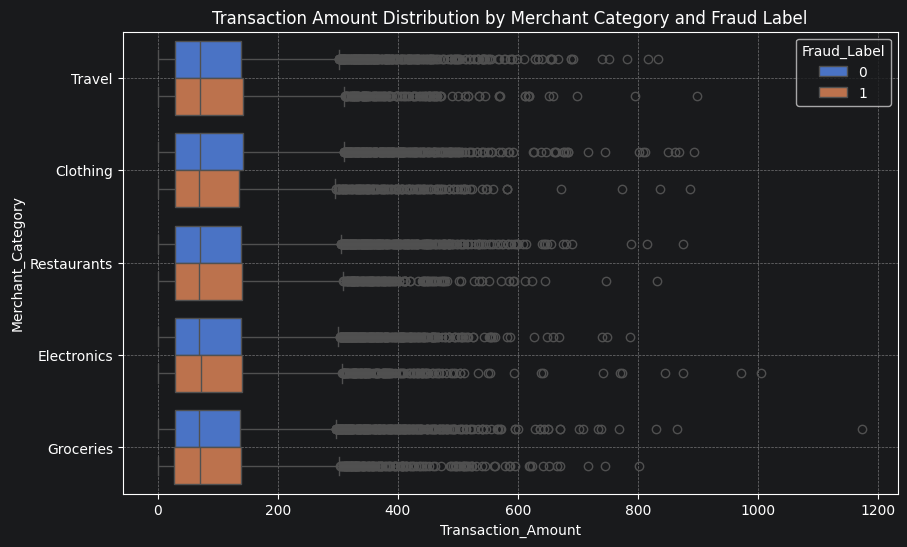

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(y='Merchant_Category', x='Transaction_Amount', data=df, hue = 'Fraud_Label')
plt.title('Transaction Amount Distribution by Merchant Category and Fraud Label')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.6)

The boxplot shows transaction amount distributions by merchant category and fraud label. Across Travel, Clothing, Restaurants, Electronics, and Groceries, the fraud and non-fraud groups have very similar central ranges. Their medians and interquartile ranges are close within each category, which suggests that typical transaction amounts do not differ strongly between fraudulent and legitimate transactions.

All merchant categories show right-skewed distributions with many high-value outliers. Groceries and Electronics appear to include some of the largest individual outliers, reaching close to or above 1,000, while Travel, Clothing, and Restaurants also show long upper tails. However, these larger amounts appear in both fraud and non-fraud transactions, so high transaction amount is not clearly tied to fraud in any one merchant category. Overall, the chart suggests that merchant category and amount may provide some context, but transaction amount alone does not clearly separate fraud from non-fraud.

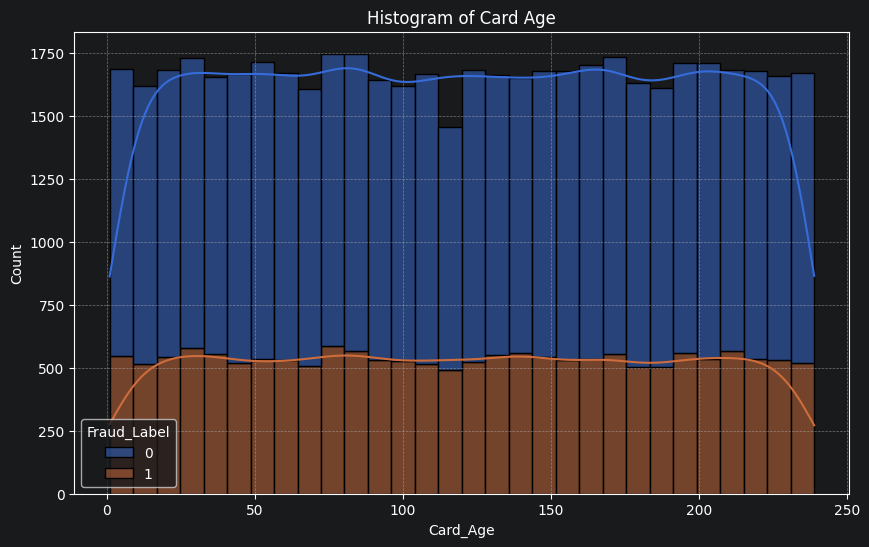

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='Card_Age',
    hue='Fraud_Label',
    bins=30,
    kde=True,
    multiple='stack'
)
plt.title('Histogram of Card Age')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

The histogram shows that card age is fairly evenly distributed across the full range, from very new cards to cards around 240 months old. There is no strong concentration in one age range, which suggests the dataset includes a balanced mix of newer and older cards. The non-fraud class appears consistently higher than the fraud class across nearly all card ages, which matches the overall class imbalance where non-fraud transactions are more common.

The fraud and non-fraud distributions have very similar shapes, meaning card age does not appear to separate the two classes clearly. Fraud cases are present across the full card-age range rather than being concentrated among either newer or older cards. This suggests that card age alone is unlikely to be a strong fraud predictor, although it may still contribute some value when combined with other variables such as risk score, device type, transaction behavior, or authentication method.

## Cleaning the Data/Engineering the Data

### Making a copy

In [16]:
cleaned_df = df.copy()

### Removing Columns

In [17]:
cleaned_df = cleaned_df.drop(columns=["Transaction_ID", "User_ID", 'Failed_Transaction_Count_7d'])

### Extracting Time Information

In [18]:
cleaned_df["Timestamp"] = pd.to_datetime(cleaned_df["Timestamp"])
cleaned_df["Hour"] = cleaned_df["Timestamp"].dt.hour
cleaned_df["Day"] = cleaned_df["Timestamp"].dt.day
cleaned_df["Month"] = cleaned_df["Timestamp"].dt.month
cleaned_df = cleaned_df.drop(columns=["Timestamp"])

### One-Hot Encoding

In [19]:
categorical_columns = [
    "Transaction_Type",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "Card_Type",
    "Authentication_Method"
]

cleaned_df = pd.get_dummies(
    cleaned_df,
    columns=categorical_columns,
    drop_first=False
)

### Original vs Cleaned Dataset Shape

In [20]:
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", cleaned_df.shape)

Original dataset shape: (50000, 21)
Cleaned dataset shape: (50000, 39)


In [21]:
cleaned_df.to_csv('synthetic_data.csv')

## Train Test Split

80% Training
20% Testing

In [22]:
train_test_df = pd.read_csv('synthetic_data.csv')

X = train_test_df.drop(columns=['Fraud_Label'])
y = train_test_df['Fraud_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train size:", len(X_train), f'---> {np.round(100*len(X_train)/(len(X_train)+len(X_test)))}%')
print("y_train size:", len(y_train), f'---> {np.round(100*len(y_train)/(len(y_train)+len(y_test)))}%')
print("\nX_test size:", len(X_test), f'---> {np.round(100*len(X_test)/(len(X_train)+len(X_test)))}%')
print("y_test size:", len(y_test), f'---> {np.round(100*len(y_test)/(len(y_train)+len(y_test)))}%')

X_train size: 40000 ---> 80.0%
y_train size: 40000 ---> 80.0%

X_test size: 10000 ---> 20.0%
y_test size: 10000 ---> 20.0%


## Feature Engineering

### Oversampling the Minority Class

In [23]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}, {y_train_res.shape}")

print("\nOriginal class distribution:")
print(y_train.value_counts())

print("\nResampled class distribution:")
print(y_train_res.value_counts())

Original training shape: (40000, 39), (40000,)
Resampled training shape: (54336, 39), (54336,)

Original class distribution:
Fraud_Label
0    27168
1    12832
Name: count, dtype: int64

Resampled class distribution:
Fraud_Label
1    27168
0    27168
Name: count, dtype: int64


**Step by step:**

1. **Create SMOTE object**

```python
smote = SMOTE(random_state=42)
```

* **SMOTE** = Synthetic Minority Oversampling Technique
* It **creates synthetic samples** for the minority class to balance the dataset.
* `random_state` ensures reproducibility.

2. **Resample the data**

```python
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
```

* Balances the classes in `y_train` by generating new synthetic samples for the minority class.
* `X_train_res` and `y_train_res` are now **balanced** datasets.

3. **Check dataset sizes**

```python
print(f"Original training shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}, {y_train_res.shape}")
```

* Shows how many rows/columns you had before and after oversampling.


### Correlation Heatmap

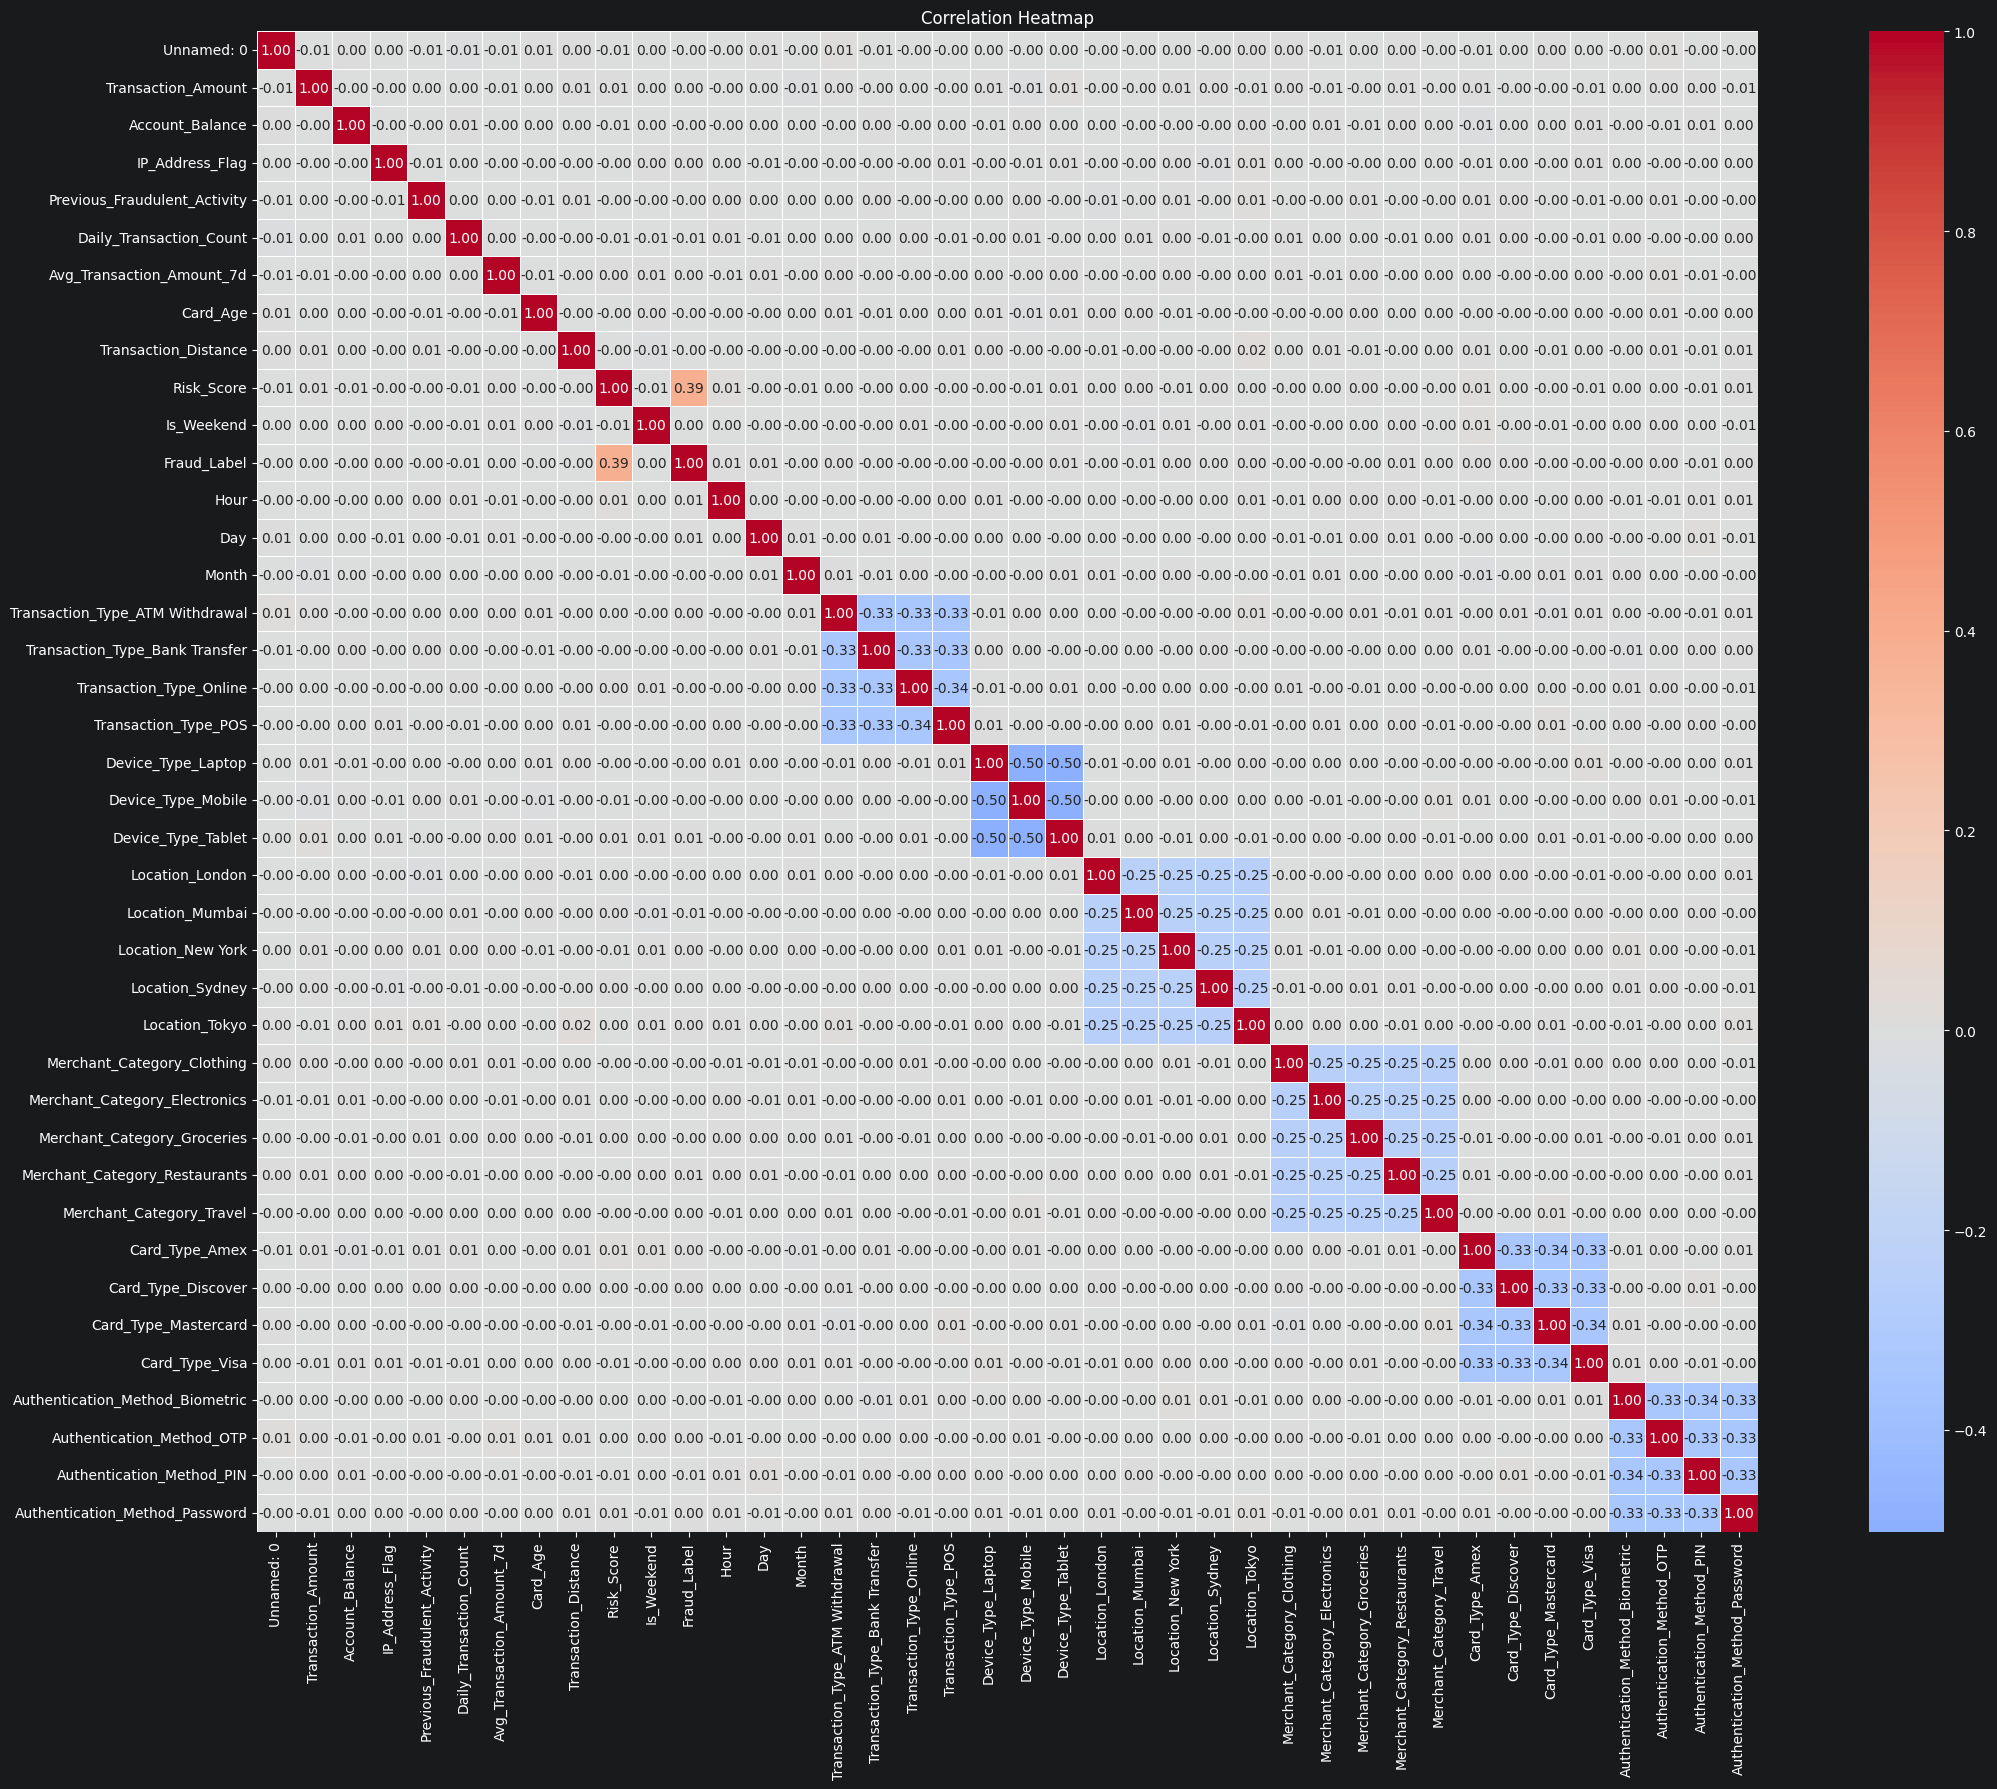

In [24]:
corr_matrix = train_test_df.corr(numeric_only=True)

plt.figure(figsize=(24, 18))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()



The correlation heatmap shows that most variables have very weak linear relationships with each other, with correlations close to 0. This means features such as transaction amount, account balance, transaction distance, transaction count, hour, day, month, card age, and most encoded categorical variables do not show strong linear associations in this dataset. The most meaningful relationship appears between `Risk_Score` and `Fraud_Label`, with a correlation of about 0.39, suggesting that higher risk scores are moderately associated with fraud.

The negative correlations among one-hot encoded categories are expected and should not be interpreted as meaningful behavioral patterns. For example, transaction type, device type, location, merchant category, card type, and authentication method dummy variables are negatively correlated with one another because each transaction can belong to only one category within each group. Overall, the heatmap suggests that fraud is not strongly explained by any single raw feature except `Risk_Score` to some extent. This supports using a machine learning model that can combine multiple weak signals rather than relying on simple one-variable relationships.

## Modeling

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

Training Datasets to be used

---


`X_train_res`\
`y_train_res`

\
Testing Datasets to be used


---
`X_test`\
`y_test`




### Random Forest

In [26]:
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ])

rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2']
    }

rf_grid = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=3
)

In [27]:
rf_grid.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__max_depth': [None, 10, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that c

### Decision Tree

In [28]:
dt_pipeline = Pipeline([
    ('dt', DecisionTreeClassifier(random_state=42))
    ])

dt_param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4],
    'dt__max_features': [None, 'sqrt', 'log2'],
    'dt__criterion': ['gini', 'entropy']
}

dt_grid = RandomizedSearchCV(
    dt_pipeline,
    dt_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=3
)

In [29]:
dt_grid.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'dt__criterion': ['gini', 'entropy'], 'dt__max_depth': [None, 10, ...], 'dt__max_features': [None, 'sqrt', ...], 'dt__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

### Logistic Regression

In [30]:
lr_pipeline = Pipeline([
    ('lr', LogisticRegression(random_state=42, max_iter=5000))
])

lr_param_grid = [
    {
        'lr__penalty': ['l1'],
        'lr__solver': ['liblinear', 'saga'],
        'lr__C': [0.001, 0.01, 0.1, 1, 10],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'lr__penalty': ['l2'],
        'lr__solver': ['liblinear', 'saga'],
        'lr__C': [0.001, 0.01, 0.1, 1, 10],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'lr__penalty': ['elasticnet'],
        'lr__solver': ['saga'],
        'lr__C': [0.001, 0.01, 0.1, 1, 10],
        'lr__l1_ratio': [0.1, 0.5, 0.9],
        'lr__class_weight': [None, 'balanced']
    }
]

lr_grid = RandomizedSearchCV(
    lr_pipeline,
    lr_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=3,
    random_state=42
)

In [31]:
lr_grid.fit(X_train_res, y_train_res)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\sjuzz\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sjuzz\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'lr__C': [0.001, 0.01, ...], 'lr__class_weight': [None, 'balanced'], 'lr__penalty': ['l1'], 'lr__solver': ['liblinear', 'saga']}, {'lr__C': [0.001, 0.01, ...], 'lr__class_weight': [None, 'balanced'], 'lr__penalty': ['l2'], 'lr__solver': ['liblinear', 'saga']}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so 

In [32]:
best_params_rf = rf_grid.best_params_
best_params_dt = dt_grid.best_params_
best_params_lr = lr_grid.best_params_

with open("best_params.txt", "w") as f:
    f.write("Random Forest Parameters:\n")
    for key, value in best_params_rf.items():
        f.write(f"{key}: {value}\n")

    f.write("\nDecision Tree Parameters:\n")
    for key, value in best_params_dt.items():
        f.write(f"{key}: {value}\n")

    f.write("\nLogistic Regression Parameters:\n")
    for key, value in best_params_lr.items():
        f.write(f"{key}: {value}\n")

### Key Metrics for Evaluating Classification Models

In [33]:
y_pred_rf = rf_grid.predict(X_test)
y_pred_dt = dt_grid.predict(X_test)

best_lr = lr_grid.best_estimator_.named_steps['lr']
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.40).astype(int)

y_pred_train_rf = rf_grid.predict(X_train_res)
y_pred_train_dt = dt_grid.predict(X_train_res)

y_prob_train_lr = best_lr.predict_proba(X_train_res)[:, 1]
y_pred_train_lr = (y_prob_train_lr >= 0.40).astype(int)

#### Random Forest Metrics

In [34]:
report = classification_report(
    y_test, y_pred_rf,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df = report_df[['precision', 'recall', 'f1-score', 'support']].round(2)

report_df.rename(index={
    '0': 'Not Fraud',
    '1': 'Fraud',
    'accuracy': 'Accuracy',
    'macro avg': 'Macro Average',
    'weighted avg': 'Weighted Average'
}, inplace=True)

report_df.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1 Score',
    'support': '# of Transactions'
}, inplace=True)

rf_metrics = report_df.head(2)

#### Decision Tree Metrics

In [35]:
report = classification_report(
    y_test, y_pred_dt,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df = report_df[['precision', 'recall', 'f1-score', 'support']].round(2)

report_df.rename(index={
    '0': 'Not Fraud',
    '1': 'Fraud',
    'accuracy': 'Accuracy',
    'macro avg': 'Macro Average',
    'weighted avg': 'Weighted Average'
}, inplace=True)

report_df.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1 Score',
    'support': '# of Transactions'
}, inplace=True)

dt_metrics = report_df.head(2)

#### Logistic Regression Metrics

In [36]:
report = classification_report(
    y_test, y_pred_lr,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df = report_df[['precision', 'recall', 'f1-score', 'support']].round(2)

report_df.rename(index={
    '0': 'Not Fraud',
    '1': 'Fraud',
    'accuracy': 'Accuracy',
    'macro avg': 'Macro Average',
    'weighted avg': 'Weighted Average'
}, inplace=True)

report_df.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1 Score',
    'support': '# of Transactions'
}, inplace=True)

lr_metrics = report_df.head(2)

#### Testing Metrics for Random Forest, Decision Tree, Logistic Regression

In [37]:
print("Random Forest Metrics:")
print(rf_metrics)

print("\nDecision Tree Metrics:")
print(dt_metrics)

print("\nLogistic Regression Metrics:")
print(lr_metrics)

Random Forest Metrics:
           Precision  Recall  F1 Score  # of Transactions
Not Fraud        0.8    1.00      0.89             6765.0
Fraud            1.0    0.47      0.64             3235.0

Decision Tree Metrics:
           Precision  Recall  F1 Score  # of Transactions
Not Fraud       0.80    0.90      0.85             6765.0
Fraud           0.71    0.52      0.60             3235.0

Logistic Regression Metrics:
           Precision  Recall  F1 Score  # of Transactions
Not Fraud       0.79    0.40      0.53             6765.0
Fraud           0.38    0.78      0.51             3235.0


The model metrics show a clear tradeoff between catching fraud and avoiding false alarms. Random Forest and Decision Tree perform almost identically. For non-fraud transactions, both models have strong performance, with precision of 0.80, recall of 1.00, and F1 score of 0.89. This means they are very good at correctly recognizing legitimate transactions. However, their fraud recall is only 0.47, meaning they detect less than half of the fraudulent transactions. Their fraud precision is 1.00, so when they do predict fraud, they are almost always correct, but they are too conservative and miss many fraud cases.

Logistic Regression behaves very differently. It has much higher fraud recall at 0.78, meaning it catches most fraudulent transactions, but its fraud precision is only 0.38. This means many transactions flagged as fraud are actually legitimate. Its non-fraud recall is also low at 0.40, showing that it misclassifies a large number of legitimate transactions as fraud. Overall, Random Forest and Decision Tree are better if the goal is to minimize false positives, while Logistic Regression is better if the priority is catching more fraud. For a fraud detection system, Logistic Regression may be more useful as a starting point for fraud screening, but it would need threshold tuning to reduce false alerts.

#### Confusion Matrices for Random Forest, Decision Tree, Logistic Regression

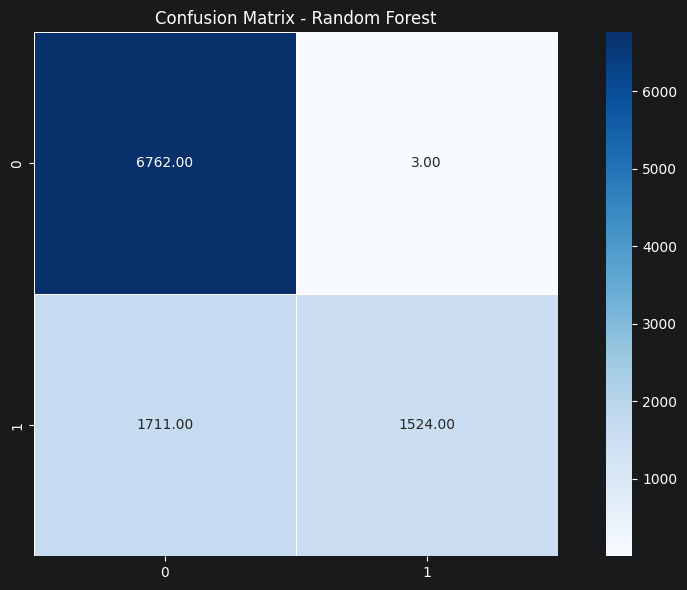

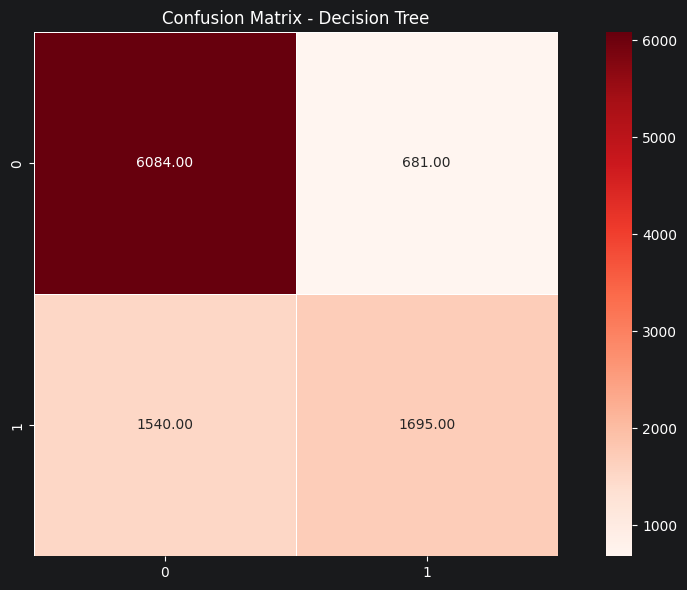

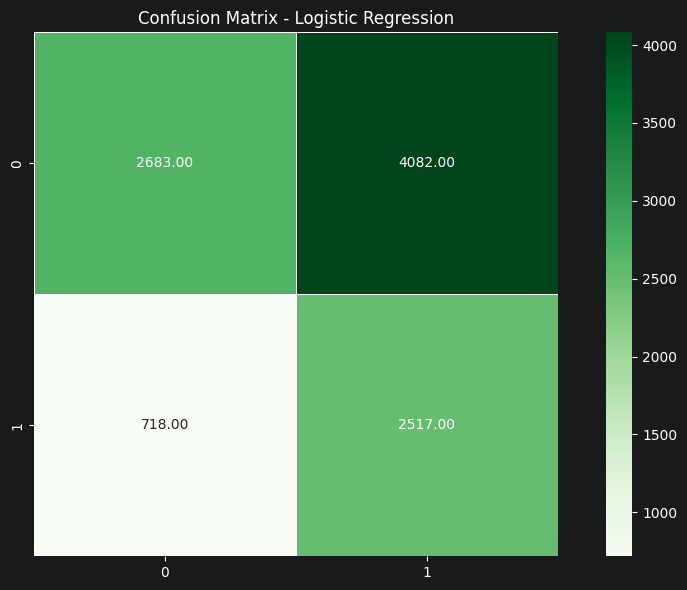

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cmap="Blues"
)
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cmap="Reds"
)
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cmap="Greens"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

The confusion matrices show very different behavior across the three models. The Random Forest correctly identifies 6,760 non-fraud cases and 1,525 fraud cases, while making only 5 false-positive fraud predictions. However, it misses 1,710 fraud cases, meaning many fraudulent transactions are still classified as non-fraud. The Decision Tree behaves almost identically, with 6,763 true negatives, 1,524 true positives, only 2 false positives, and 1,711 false negatives. Both tree-based models are very conservative about predicting fraud: they almost never incorrectly flag legitimate transactions, but they fail to catch a large share of fraud cases.

The Logistic Regression model shows the opposite pattern. It correctly identifies more fraud cases, with 2,517 true positives and only 718 false negatives, so it has much stronger fraud recall. However, it also incorrectly flags 4,082 non-fraud transactions as fraud, which is a very high false-positive count. This means Logistic Regression is much more aggressive in predicting fraud, but at the cost of overwhelming the system with many incorrect fraud alerts. 

Overall, the best model depends on the business goal: if minimizing false alarms is most important, Random Forest or Decision Tree performs better; if catching more fraud is more important, Logistic Regression is stronger, though it may need threshold tuning to reduce false positives.

### Feature Importance

#### Random Forest Feature Importances

In [39]:
best_rf = rf_grid.best_estimator_.named_steps['rf']

rf_importance = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': best_rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

print(rf_importance.reset_index(drop=True))

                            Feature  Importance
0                        Risk_Score    0.320117
1                Device_Type_Mobile    0.037847
2                Device_Type_Tablet    0.032880
3                Device_Type_Laptop    0.032561
4                   Account_Balance    0.026414
5         Avg_Transaction_Amount_7d    0.026107
6                        Unnamed: 0    0.026058
7                Transaction_Amount    0.025977
8              Transaction_Distance    0.025437
9                          Card_Age    0.024889
10                   Card_Type_Visa    0.021393
11             Card_Type_Mastercard    0.021083
12        Authentication_Method_PIN    0.020838
13   Transaction_Type_Bank Transfer    0.020021
14                              Day    0.019930
15             Transaction_Type_POS    0.019787
16  Authentication_Method_Biometric    0.019286
17                             Hour    0.019072
18               Card_Type_Discover    0.018814
19                   Card_Type_Amex    0

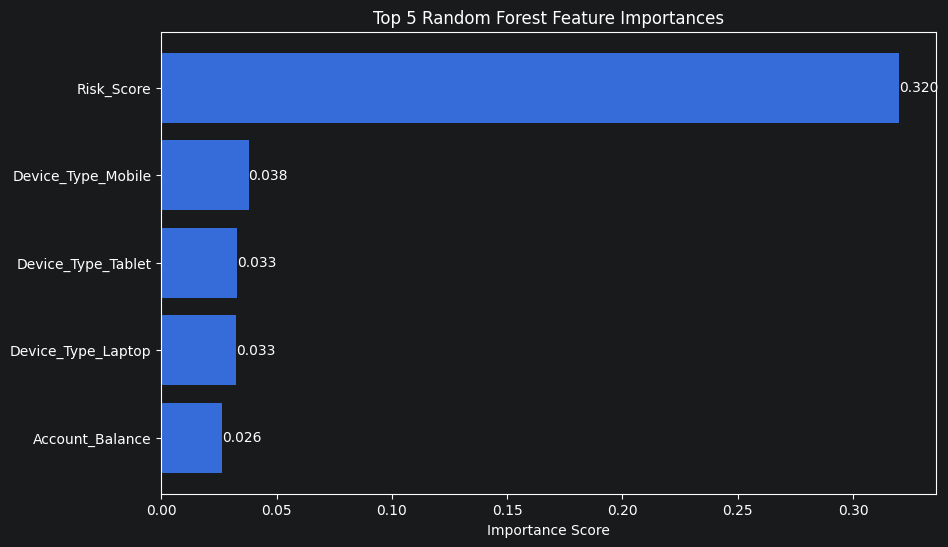

In [40]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    rf_importance['Feature'].head(5),
    rf_importance['Importance'].head(5)
)

plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 5 Random Forest Feature Importances")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,                         # x-position
        bar.get_y() + bar.get_height()/2,  # y-position
        f"{width:.3f}",                # label text
        va="center",
        ha="left"
    )

plt.show()

The chart shows that `Risk_Score` is the dominant predictor in the Random Forest model, with an importance score of 0.300. This is much higher than the other top features, meaning the model depends heavily on risk score when separating fraud from non-fraud. The next most important variables are `Device_Type_Mobile` at 0.042, `Device_Type_Laptop` at 0.035, `Account_Balance` at 0.032, and `Unnamed: 0` at 0.031, but these contribute far less individually.

This suggests that most of the model’s predictive power is coming from `Risk_Score`, while device type and account balance provide smaller supporting signals. The presence of `Unnamed: 0` is a concern because it is likely just an index column created when the CSV was saved. Since it does not represent real transaction behavior, it should be removed before training the model. Overall, the feature importance results indicate that the Random Forest model is not relying equally on many variables; instead, it is largely driven by one strong feature.

#### Decision Tree Feature Importances

In [41]:
best_dt = dt_grid.best_estimator_.named_steps['dt']

dt_importance = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': best_dt.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by='Importance',
    ascending=False
)

print(dt_importance.reset_index(drop=True))

                            Feature  Importance
0                        Risk_Score    0.347881
1                Device_Type_Mobile    0.178769
2                Device_Type_Laptop    0.077489
3                   Account_Balance    0.028657
4                        Unnamed: 0    0.028276
5                Transaction_Amount    0.026849
6              Transaction_Distance    0.026121
7         Avg_Transaction_Amount_7d    0.022916
8                          Card_Age    0.020385
9              Card_Type_Mastercard    0.019211
10                   Card_Type_Visa    0.017843
11               Device_Type_Tablet    0.015917
12          Transaction_Type_Online    0.015528
13                              Day    0.014615
14                   Card_Type_Amex    0.013115
15               Card_Type_Discover    0.012762
16                             Hour    0.012517
17   Transaction_Type_Bank Transfer    0.011312
18                            Month    0.010634
19          Daily_Transaction_Count    0

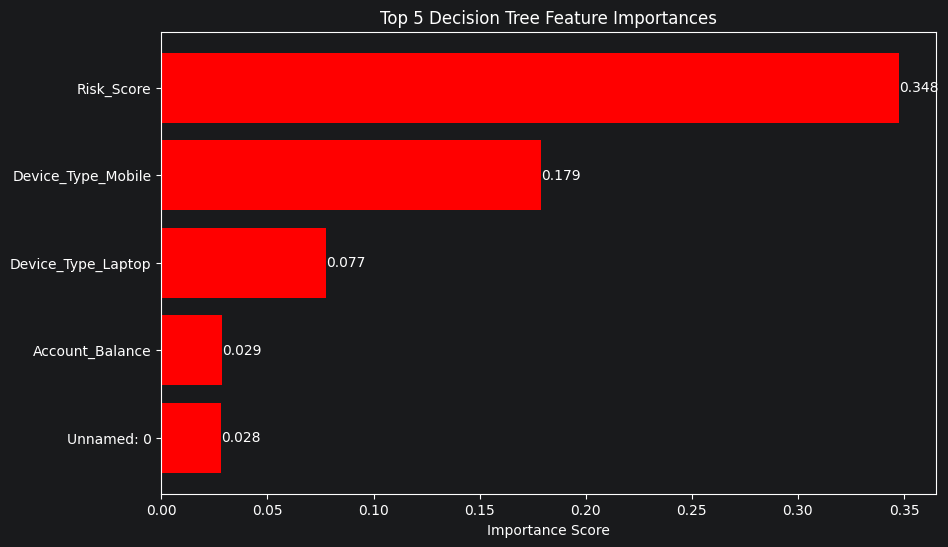

In [42]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    dt_importance['Feature'].head(5),
    dt_importance['Importance'].head(5),
    color='red'
)

plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 5 Decision Tree Feature Importances")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,                         # x-position
        bar.get_y() + bar.get_height()/2,  # y-position
        f"{width:.3f}",                # label text
        va="center",
        ha="left"
    )

plt.show()

The Decision Tree feature importance chart shows that `Risk_Score` is the most important predictor, with an importance score of 0.434. This means the tree relies heavily on risk score when deciding whether a transaction is fraudulent. The second strongest feature is `Device_Type_Mobile` at 0.254, followed by `Device_Type_Laptop` at 0.107. Together, these top three features account for most of the model’s decision-making.

Compared with the Random Forest, the Decision Tree places even more concentrated importance on a small number of features. Device type appears especially influential here, particularly mobile transactions. `Device_Type_Tablet` and `Card_Type_Visa` have much smaller importance scores, at 0.026 and 0.024, so they provide only minor additional signal. Overall, the chart suggests that the Decision Tree model is mainly driven by `Risk_Score` and device type, while most other variables contribute relatively little.

#### Logistic Regression Feature Importances

In [43]:
best_lr = lr_grid.best_estimator_.named_steps['lr']

lr_importance = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': abs(best_lr.coef_[0])
})

lr_importance = lr_importance.sort_values(
    by='Importance',
    ascending=False
)

print(lr_importance.reset_index(drop=True))

                            Feature  Importance
0                        Risk_Score    1.777108
1                Device_Type_Tablet    0.411423
2                Device_Type_Laptop    0.381441
3                Device_Type_Mobile    0.356854
4                        Is_Weekend    0.131735
5                             Month    0.033959
6           Daily_Transaction_Count    0.030513
7                              Hour    0.011827
8   Transaction_Type_ATM Withdrawal    0.007926
9                               Day    0.007306
10                         Card_Age    0.001371
11        Avg_Transaction_Amount_7d    0.000489
12               Transaction_Amount    0.000406
13             Transaction_Distance    0.000050
14                       Unnamed: 0    0.000004
15                  Account_Balance    0.000002
16     Previous_Fraudulent_Activity    0.000000
17                  IP_Address_Flag    0.000000
18   Transaction_Type_Bank Transfer    0.000000
19             Transaction_Type_POS    0

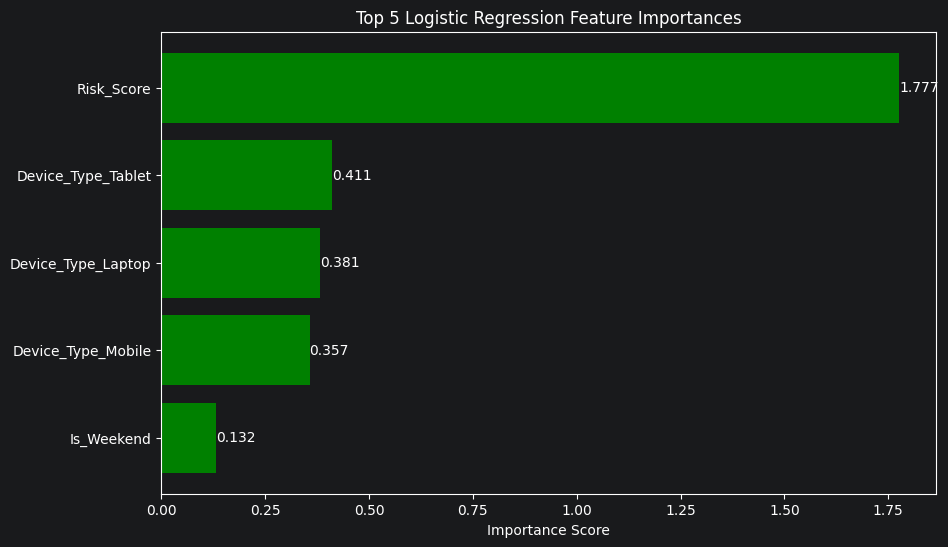

In [44]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    lr_importance['Feature'].head(5),
    lr_importance['Importance'].head(5),
    color='green'
)

plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 5 Logistic Regression Feature Importances")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,                         # x-position
        bar.get_y() + bar.get_height()/2,  # y-position
        f"{width:.3f}",                # label text
        va="center",
        ha="left"
    )

plt.show()

The Logistic Regression feature importance chart shows that `Risk_Score` has the strongest influence on the model by a large margin, with an importance score of 1.777. This means increases in risk score are strongly associated with the model predicting fraud. The next most influential features are device-related: `Device_Type_Tablet` at 0.411, `Device_Type_Laptop` at 0.381, and `Device_Type_Mobile` at 0.357. `Is_Weekend` has a smaller but still visible influence at 0.132.

These results suggest that Logistic Regression is mainly driven by `Risk_Score`, with device type providing additional predictive signal. Compared with the tree-based models, Logistic Regression gives more balanced attention to different device categories, while still relying most heavily on risk score. Since Logistic Regression coefficients are sensitive to feature scaling and encoding, these importance values should be interpreted carefully. Overall, the model appears to associate higher risk scores and certain device types with a greater likelihood of fraud.

### ROC AUC Curve

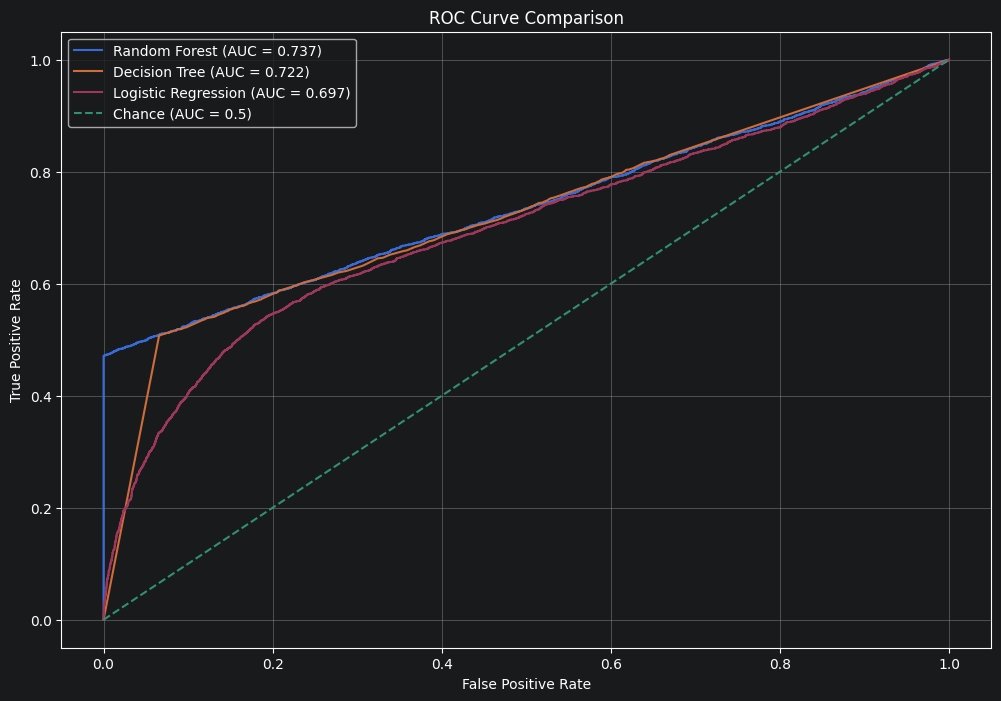

In [45]:
models = {
    "Random Forest": rf_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_
}

plt.figure(figsize=(12, 8))

for name, model in models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

The ROC curve comparison shows that all three models perform better than random guessing, since their curves stay above the diagonal baseline. The Random Forest has the highest AUC at 0.737, followed closely by the Decision Tree at 0.734, while Logistic Regression has a lower AUC of 0.697. This means the Random Forest has the best overall ability to distinguish between fraud and non-fraud across different classification thresholds, but the difference between Random Forest and Decision Tree is very small.

The shape of the curves also matches the earlier confusion matrices. The tree-based models appear stronger overall by AUC, but their default thresholds were very conservative and missed many fraud cases. Logistic Regression has a slightly weaker AUC, but it produced higher fraud recall at the default threshold while also creating many false positives. Overall, Random Forest looks like the strongest model by ROC-AUC, but threshold tuning would be important before choosing a final model, especially because fraud detection often prioritizes catching fraud over simply maximizing overall discrimination.

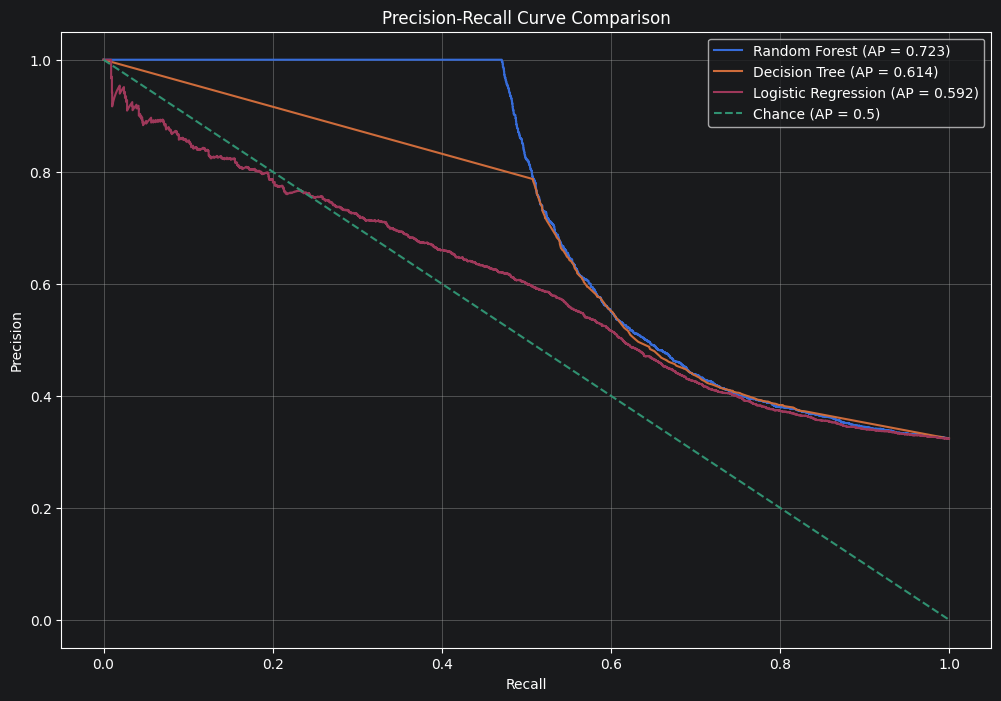

In [47]:
models = {
    "Random Forest": rf_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_
}

plt.figure(figsize=(12, 8))

for name, model in models.items():
    y_score = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    avg_precision = average_precision_score(y_test, y_score)

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {avg_precision:.3f})"
    )
plt.plot([0,1], [1,0], linestyle="--", label="Chance (AP = 0.5)")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

The precision-recall curve shows that the Random Forest performs best overall, with the highest average precision of 0.723. The Decision Tree is very close behind with an average precision of 0.715, while Logistic Regression is noticeably lower at 0.592. Since precision-recall curves are especially useful for fraud detection, this suggests that the tree-based models are better at maintaining precision while recall changes across different thresholds.

The curve also shows the same tradeoff seen in the confusion matrices and metric tables. Random Forest and Decision Tree can achieve very high precision when recall is around the midrange, meaning their fraud predictions are reliable when they choose to flag transactions. However, as recall increases, precision drops because the models begin capturing more fraud at the cost of more false positives. Logistic Regression starts with stronger recall behavior but has lower precision overall, so it catches more fraud more aggressively but produces more incorrect fraud alerts. Overall, Random Forest appears to be the strongest model by average precision, but the final choice should depend on the preferred balance between fraud detection and false alarms.